In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
import os

os.environ["PYSPARK_SUBMIT_ARGS"] = (
    "--driver-class-path /Users/sydneysailors/smart-store-sydney/lib/sqlite-jdbc-3.51.0.0.jar "
    "--jars /Users/sydneysailors/smart-store-sydney/lib/sqlite-jdbc-3.51.0.0.jar "
    "pyspark-shell"
)

In [ ]:
from pyspark.sql import SparkSession

dw_path = "/Users/sydneysailors/smart-store-sydney/data/dw/smart_sales.db"

spark = SparkSession.builder.appName("SmartStoreReporing").getOrCreate()

# Test driver
spark._jvm.java.lang.Class.forName("org.sqlite.JDBC")

JavaObject id=o88

In [24]:
sales_df = (
    spark.read.format("jdbc")
    .options(url=f"jdbc:sqlite:{dw_path}", dbtable="sales", driver="org.sqlite.JDBC")
    .load()
)

sales_df.show(5)

+-------+---------+-----------+----------+--------+-----------+------------+---------------+-----+
|sale_id|sale_date|customer_id|product_id|store_id|campaign_id|sales_amount|discount_amount|state|
+-------+---------+-----------+----------+--------+-----------+------------+---------------+-----+
|      1|   5/4/25|       1034|      2059|     402|        0.0|      2048.2|          12.45|   CA|
|      2|   5/4/25|       1066|      2048|     403|        1.0|      321.87|            7.8|   NY|
|      3|   5/4/25|       1116|      2041|     403|        3.0|     3216.84|           25.0|   TX|
|      4|   5/4/25|       1071|      2096|     404|        2.0|     1613.23|           18.3|   FL|
|      5|   5/4/25|       1020|      2060|     401|        0.0|      408.38|            5.5|   IL|
+-------+---------+-----------+----------+--------+-----------+------------+---------------+-----+
only showing top 5 rows


In [25]:
customers_df = (
    spark.read.format("jdbc")
    .options(url=f"jdbc:sqlite:{dw_path}", dbtable="customers", driver="org.sqlite.JDBC")
    .load()
)

products_df = (
    spark.read.format("jdbc")
    .options(url=f"jdbc:sqlite:{dw_path}", dbtable="products", driver="org.sqlite.JDBC")
    .load()
)

customers_df.show(5)
products_df.show(5)

+-----------+-------------+-------+---------+---+-------------------+
|customer_id|         name| region|join_date|age|subscription_status|
+-----------+-------------+-------+---------+---+-------------------+
|       1000| Robert Gomez|   West|  2/25/24| 49|            Expired|
|       1001|   John Silva|   East|  12/1/20| 48|              Trial|
|       1002|Mark Marshall|Central|   8/8/20| 37|              Trial|
|       1003|David Brennan|  North|  5/21/20| 71|              Trial|
|       1004|Kerry Collins|  North|  9/12/23| 61|            Expired|
+-----------+-------------+-------+---------+---+-------------------+
only showing top 5 rows
+----------+--------------------+-----------+----------+----------------+-------------------+
|product_id|        product_name|   category|unit_price|manufacture_year|availability_status|
+----------+--------------------+-----------+----------+----------------+-------------------+
|      2000|      Electronics-Be|Electronics|     969.0|        

In [26]:
sales_df.createOrReplaceTempView("sale")
customers_df.createOrReplaceTempView("customer")
products_df.createOrReplaceTempView("product")

In [27]:
slice_df = spark.sql("""
    SELECT *
    FROM product
    WHERE availability_status = 'In stock'
""")
slice_df.show(10)

+----------+--------------------+-----------+----------+----------------+-------------------+
|product_id|        product_name|   category|unit_price|manufacture_year|availability_status|
+----------+--------------------+-----------+----------+----------------+-------------------+
|      2000|      Electronics-Be|Electronics|     969.0|            2021|           In stock|
|      2003|Electronics-Training|   Clothing|     385.0|            2025|           In stock|
|      2004|        Office-Where|       Home|     927.0|            2012|           In stock|
|      2007|       Clothing-Over|Electronics|     583.0|            2003|           In stock|
|      2008|    Electronics-Skin|       Home|      67.0|            2018|           In stock|
|      2011|Electronics-Relig...|   Clothing|     410.0|            2015|           In stock|
|      2013|     Office-Cultural|       Home|     935.0|            2011|           In stock|
|      2015|       Office-Itself|   Clothing|     675.0|    

In [28]:
dice_df = spark.sql("""
    SELECT
        c.region,
        c.age,
        SUM(s.sales_amount) AS total_sales
    FROM sale s
    JOIN customer c
        ON s.customer_id = c.customer_id
    WHERE c.region = 'North'
    GROUP BY c.region, c.age
""")

dice_df.show(10)

+------+---+------------------+
|region|age|       total_sales|
+------+---+------------------+
| North| 34|          11962.33|
| North| 65|10941.630000000001|
| North| 36|           9392.62|
| North| 23|13868.880000000003|
| North| 57| 7894.779999999999|
| North| 43| 8223.570000000002|
| North| 71|          22362.35|
| North| 27|          11311.07|
| North| 26|22685.100000000002|
| North| 49|          12786.41|
+------+---+------------------+
only showing top 10 rows


In [29]:
drill_df = spark.sql("""
    SELECT
        c.region,
        s.store_id,
        SUM(s.sales_amount) AS total_sales,
        COUNT(s.sale_id) AS num_transactions
    FROM sale s
    JOIN customer c
        ON s.customer_id = c.customer_id
    GROUP BY c.region, s.store_id
    ORDER BY c.region, total_sales DESC
""")

drill_df.show(10)

+-------+--------+------------------+----------------+
| region|store_id|       total_sales|num_transactions|
+-------+--------+------------------+----------------+
|Central|     401|          48793.89|              43|
|Central|     404| 43223.80000000002|              39|
|Central|     402| 40321.21000000001|              39|
|Central|     403|39292.100000000006|              33|
|   EAST|     404| 82431.05999999995|              67|
|   EAST|     403| 55088.31999999999|              47|
|   EAST|     402| 51482.55999999999|              42|
|   EAST|     401| 49170.39000000003|              53|
|   East|     403|          59336.56|              49|
|   East|     402| 50525.56000000001|              42|
+-------+--------+------------------+----------------+
only showing top 10 rows


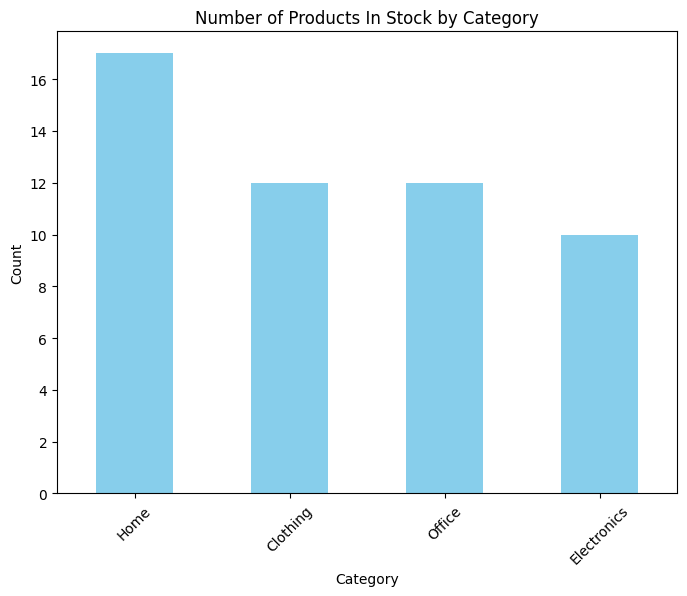

In [30]:
# Import Matplotlib
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas
pdf = slice_df.toPandas()

# Count products per category
category_counts = pdf['category'].value_counts()

# Plot a bar chart
plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Products In Stock by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

/var/folders/w9/y87mzhss6m728jcnq5wwhrbw0000gn/T/ipykernel_49304/3362022644.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_sales = pdf.groupby('age_group')['total_sales'].sum()


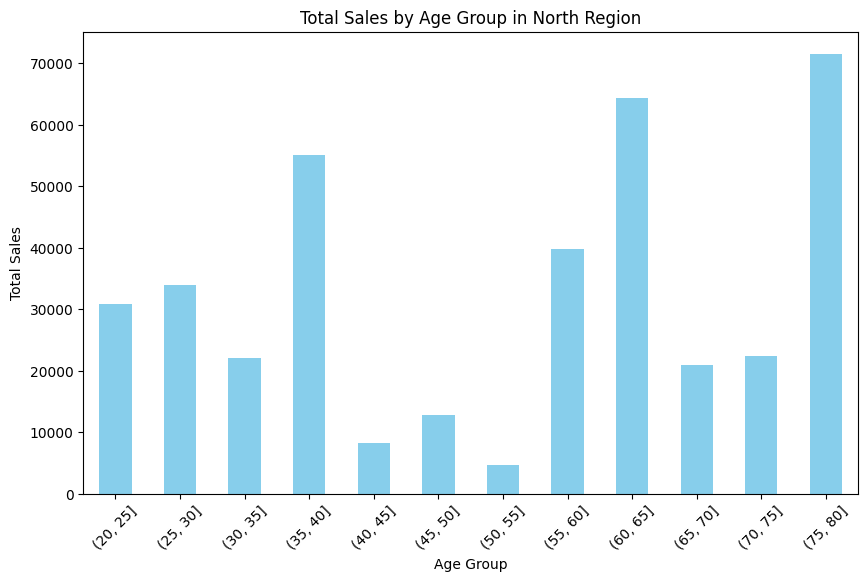

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas
pdf = dice_df.toPandas()

# Group ages into bins (20-24, 25-29, ..., 75-80)
pdf['age_group'] = pd.cut(pdf['age'], bins=range(20, 81, 5))

# Sum total sales per age group
age_group_sales = pdf.groupby('age_group')['total_sales'].sum()

# Plot
age_group_sales.plot(kind='bar', color='skyblue', figsize=(10, 6))
plt.title('Total Sales by Age Group in North Region')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

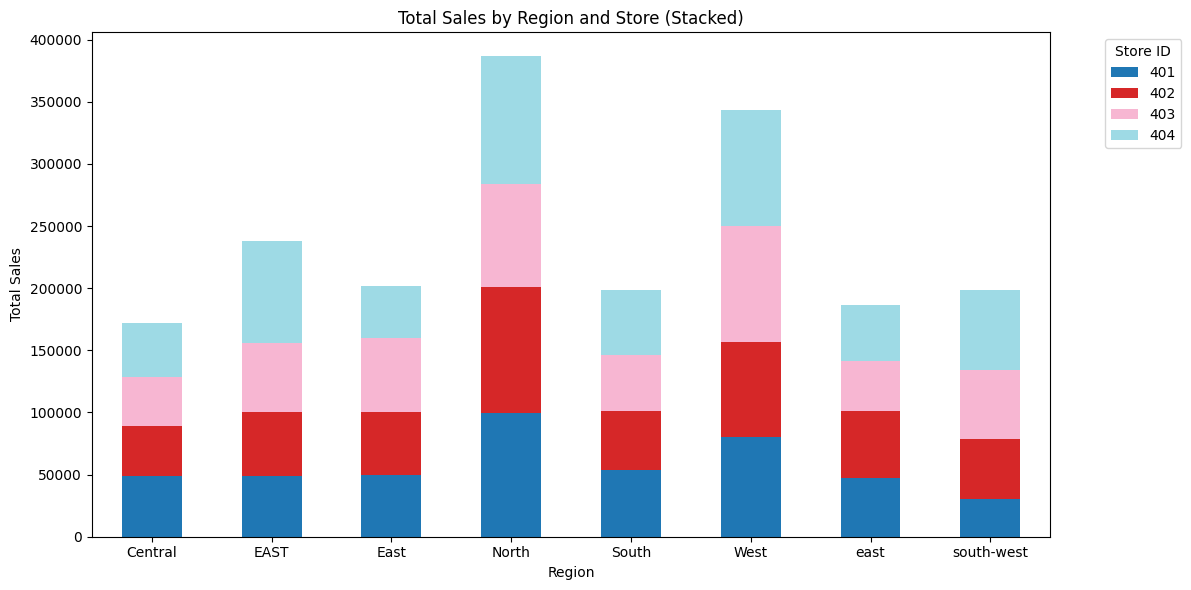

In [32]:
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas
pdf = drill_df.toPandas()

# Pivot the data: index=region, columns=store_id, values=total_sales
pivot_df = pdf.pivot(index='region', columns='store_id', values='total_sales')

# Plot stacked bar chart
pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Total Sales by Region and Store (Stacked)')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.legend(
    title='Store ID', bbox_to_anchor=(1.05, 1), loc='upper left'
)  # moves legend outside plot
plt.tight_layout()
plt.show()